# Validation: stochastic observability & constructability

This notebook checks `pybounds.stochastic` -- the stochastic observability and constructability Gramians behind the
`stochastic-*` methods of `ObservabilityAnalysis` -- against Burak Boyacioglu's MATLAB reference implementation of

> B. Boyacioglu & F. van Breugel, "Duality of Stochastic Observability and Constructability and their Relation to the
> Fisher Information", *IEEE Control Systems Letters* (2025), doi:[10.1109/LCSYS.2025.3547297](https://doi.org/10.1109/LCSYS.2025.3547297)

and redraws **Fig. 2** of that letter with pybounds.

The MATLAB reference (`SLOC`) holds

| file | content |
|---|---|
| `code/stochObservabilityGram.m` | Eq. (33), the letter's own contribution |
| `code/stochConstructabilityGram.m` | Eq. (30), after Tichavsky et al. (1998) |
| `examples/observabilityExample.m` | the system and all five curves of Fig. 2 |
| `examples/bonus/constructabilityExample.m` | the Crassidis & Junkins attitude problem |

The `matlab_*` functions below are **verbatim transcriptions** of those files rather than an execution of them:
explicit `inv()` where the `.m` writes `inv()`, no symmetrization, no `solve`, and a dummy slot 0 in every array so
the 1-based index arithmetic can be copied across unchanged. They must stay that way -- the moment a port quietly
adopts one of pybounds' improvements it stops being an independent reference.

**Checks** (each must be within its tolerance; the summary at the end asserts it):

- **A.** observability recursion vs MATLAB, every window size `w = 1..31`, and Loewner monotonicity in `w`
- **B.** constructability recursion vs MATLAB, on the letter's system and on the ill-conditioned Crassidis problem
- **C.** Theorem 1 (duality): the dual system's constructability reproduces the MATLAB's green curves of Fig. 2
- **D.** the recursive formula stays stable for `w >= 25`, where the two non-recursive formulas break down
- **E.** pybounds against a 50-digit reference (runs only if `mpmath` is installed)

The last section uses the same recursions through `ObservabilityAnalysis` on a nonlinear system, to show what the
`alignment` setting does.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='.*do[-_]mpc.*')   # do_mpc's notices about its optional features

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

import pybounds
from pybounds import stochastic

np.set_printoptions(precision=12, linewidth=140)
inv = np.linalg.inv

# Colours of the published figure: `dualityGreen` is observabilityExample.m line 145, the other two are read off it
DUALITY_GREEN = np.array([106, 180, 46]) / 256.0
ORANGE = '#e8811c'
YELLOW = '#f2c832'

## Verbatim ports of the MATLAB reference

Do not "improve" these. Arrays are 1-indexed lists with a dummy slot 0.

In [2]:
def matlab_observability_gram(As, Cs, Qs, Rs, w):
    """ code/stochObservabilityGram.m """
    F_x0 = Cs[w].T @ (inv(Rs[w]) @ Cs[w])
    for i in range(1, w):                                      # for i=1:w-1
        instA = As[w - i]
        instQ = Qs[w - i]
        F_x0 = (instA.T @ inv(instQ) @ instA
                - instA.T @ inv(instQ) @ inv(F_x0 + inv(instQ)) @ inv(instQ) @ instA
                + Cs[w - i].T @ (inv(Rs[w - i]) @ Cs[w - i]))
    return F_x0


def matlab_constructability_gram(As, Cs, Qs, Rs, N, seed=None):
    """ code/stochConstructabilityGram.m, returning the whole sequence indexed 1..N+1.

    :param seed: the hardcoded `F_xw(:,:,1) = [1e4 0; 0 1e12]` of line 17, which overrides the `C^T R^-1 C` seed of
        line 16. It is the Crassidis initial covariance and so belongs to the example rather than to the method.
        None gives the line-16 seed, which is the one `stochastic_constructability_gramian` implements (a prior can
        be supplied there through its F0 argument).
    """
    F_xw = [None] * (N + 2)
    F_xw[1] = Cs[1].T @ (inv(Rs[1]) @ Cs[1])
    if seed is not None:
        F_xw[1] = np.asarray(seed, dtype=float)
    for i in range(1, N + 1):                                  # for i=1:N
        instA = As[i]
        instQ = Qs[i]
        F_xw[i + 1] = (-inv(instQ) @ instA @ inv(F_xw[i] + instA.T @ inv(instQ) @ instA)
                       @ instA.T @ inv(instQ)
                       + inv(instQ)
                       + Cs[i + 1].T @ (inv(Rs[i + 1]) @ Cs[i + 1]))
    return F_xw


def matlab_fim_tenny_rawlings(As, Cs, Qs, Rs, w, n, p):
    """ examples/observabilityExample.m lines 43-79 -- the pre-existing non-recursive formula. """
    O = Cs[1]
    prodA = np.eye(n)
    for i in range(1, w):                                      # for i = 1:(w-1)
        prodA = As[i] @ prodA
        O = np.vstack([O, Cs[i + 1] @ prodA])

    M = np.zeros((w * p, w * n))
    for block_row in range(1, w + 1):
        for block_col in range(1, w + 1):
            rows = slice((block_row - 1) * p, block_row * p)
            cols = slice((block_col - 1) * n, block_col * n)
            if block_row == 1:
                continue                                       # first row of blocks is all zeros
            elif block_row - block_col == 1:
                M[rows, cols] = Cs[block_row]
            elif block_row - block_col > 1:
                block = Cs[block_row]
                for i in range(block_row - 1, block_col, -1):  # for i=blockRow-1:-1:blockCol+1
                    block = block @ As[i]
                M[rows, cols] = block

    blkdiag_q = block_diag(*[Qs[i] for i in range(1, w + 1)])
    blkdiag_r = block_diag(*[Rs[i] for i in range(1, w + 1)])

    big_r = blkdiag_r + M @ blkdiag_q @ M.T
    return O.T @ inv(big_r) @ O


def matlab_fim_theorem_1(As, Cs, Qs, Rs, PHIs, w, n, p):
    """ examples/observabilityExample.m lines 93-124 -- the letter's own Eqs. (23-25).

    :param PHIs: dict keyed `(j, i)`, exactly the MATLAB's `PHIs(:,:,j,i)`.
    """
    O = Cs[1]
    prodA = np.eye(n)
    for i in range(1, w):
        prodA = As[i] @ prodA
        O = np.vstack([O, Cs[i + 1] @ prodA])

    sub_r = np.zeros((p * (w - 1), p * (w - 1)))
    for j in range(1, w):                                      # for j = 1:w-1
        for k in range(1, w):
            rj = slice((j - 1) * p, j * p)
            ck = slice((k - 1) * p, k * p)
            if j == k:
                sub_r[rj, ck] = Rs[j + 1]
                for i in range(1, k + 1):                      # for i=1:k
                    sub_r[rj, ck] = (sub_r[rj, ck] + Cs[j + 1] @ PHIs[(j, i)] @ Qs[i]
                                     @ PHIs[(j, i)].T @ Cs[j + 1].T)
            elif j > k:
                for i in range(1, k + 1):
                    sub_r[rj, ck] = (sub_r[rj, ck] + Cs[j + 1] @ PHIs[(j, i)] @ Qs[i]
                                     @ PHIs[(k, i)].T @ Cs[k + 1].T)
                sub_r[(k - 1) * p:k * p, (j - 1) * p:j * p] = sub_r[rj, ck].T

    big_r = np.zeros((p * w, p * w))
    big_r[:p, :p] = Rs[1]
    big_r[p:, p:] = sub_r
    return O.T @ inv(big_r) @ O

## The two example systems

The letter's own linear time-varying system (`observabilityExample.m`): two states, one measurement,

$$A_k = \begin{bmatrix} 2 & -1 \\ 0 & 1 \end{bmatrix} + \begin{bmatrix} 0 & \sin(\pi k/18) \\ \cos(\pi k/18) & 0 \end{bmatrix},
\quad C = [1 \;\; 0], \quad Q = 10^{-2}\begin{bmatrix} 3.6 & 1.2 \\ 1.2 & 6 \end{bmatrix}, \quad R = 0.1,$$

used directly as the transition matrices. And the Crassidis & Junkins (2012, pp. 165-168) single-axis attitude problem
(`constructabilityExample.m`), whose $Q$ has a condition number of $10^6$: it is where pybounds and the MATLAB stop
agreeing to machine precision.

In [3]:
def duality_example(N=30):
    """ examples/observabilityExample.m lines 6-27. Returns (As, Cs, Qs, Rs, n, p, N), 1-indexed with a dummy slot 0. """
    A = np.array([[2.0, -1.0], [0.0, 1.0]])
    C = np.array([[1.0, 0.0]])
    Q = 1e-2 * np.array([[3.6, 1.2], [1.2, 6.0]])
    R = np.array([[0.1]])

    n, p = A.shape[1], C.shape[0]
    As, Cs, Qs, Rs = ([None] * (N + 2) for _ in range(4))
    for k in range(0, N + 1):                                  # for k=0:N
        As[k + 1] = A + np.array([[0.0, np.sin(np.pi * k / 18)],
                                  [np.cos(np.pi * k / 18), 0.0]])
        Cs[k + 1], Qs[k + 1], Rs[k + 1] = C, Q, R
    return As, Cs, Qs, Rs, n, p, N


def duality_example_phis(As, n, N):
    """ examples/observabilityExample.m lines 85-91 (ported as written: the product starts from A_{i+1}). """
    PHIs = {}
    for i in range(1, N + 1):
        PHIs[(i, i)] = np.eye(n)
        for j in range(i + 1, N + 1):
            PHIs[(j, i)] = As[j] @ PHIs[(j - 1, i)]
    return PHIs


def crassidis_example(dt=1.0, tf=60 * 60):
    """ examples/bonus/constructabilityExample.m -- single-axis attitude estimation from a gyro. """
    N = int(round(tf / dt))
    A = np.array([[1.0, -dt], [0.0, 1.0]])
    C = np.array([[1.0, 0.0]])

    sig_u = np.sqrt(10) * 1e-10
    sig_v = np.sqrt(10) * 1e-7
    sig_n = 17e-6
    R = np.array([[sig_n ** 2]])
    Q = np.array([[sig_v ** 2 * dt + sig_u ** 2 * dt ** 3 / 3.0, -0.5 * sig_u ** 2 * dt ** 2],
                  [-0.5 * sig_u ** 2 * dt ** 2, sig_u ** 2 * dt]])

    As = [None] + [A] * (N + 1)
    Cs = [None] + [C] * (N + 1)
    Qs = [None] + [Q] * (N + 1)
    Rs = [None] + [R] * (N + 1)
    return As, Cs, Qs, Rs, N

## Helpers

`pybounds_observability` / `pybounds_constructability` run the pybounds recursions over a window's first `w`
samples, in pybounds' 0-indexed convention. `dual_system` builds the dual of a window exactly as
`stochastic.duality_check` does (letter p. 4: $\bar\Phi_{N,N-1} = \Phi^{-1}_{1,0}$, $\bar C_N = C_0$,
$\bar Q_{N-1} = \Phi^{-1}_{1,0} Q_0 \Phi^{-T}_{1,0}$, $\bar R_N = R_0$, with $N = w - 1$); it is reproduced here
because Fig. 2's green curves are its *intermediate* iterates, which `duality_check` does not return.

In [4]:
def relative(a, b):
    """ Relative difference in Frobenius norm. """
    denominator = max(np.linalg.norm(a), np.linalg.norm(b))
    return np.linalg.norm(a - b) / denominator if denominator else np.linalg.norm(a - b)


def zero_indexed(As, Cs, Qs, Rs, w):
    """ The first `w` samples in pybounds' 0-indexed convention. """
    return ([As[j + 1] for j in range(w)], [Cs[j + 1] for j in range(w)],
            [Qs[j + 1] for j in range(w)], [Rs[j + 1] for j in range(w)])


def dual_system(Phis, Cs, Qds, Rs):
    """ The dual of a w-step window. Returns (dual_Phis, dual_Cs, dual_Qinvs, dual_Rinvs). """
    w = len(Cs)
    n = Phis[0].shape[0]
    Phi_inv = [inv(P) for P in Phis]
    return ([Phi_inv[w - 2 - k] for k in range(w - 1)] + [np.eye(n)],
            [Cs[w - 1 - k] for k in range(w)],
            [inv(Phi_inv[w - 2 - k] @ Qds[w - 2 - k] @ Phi_inv[w - 2 - k].T)
             for k in range(w - 1)] + [np.eye(n)],
            [inv(Rs[w - 1 - k]) for k in range(w)])


def pybounds_observability(As, Cs, Qs, Rs, w):
    Phis, Cw, Qds, Rw = zero_indexed(As, Cs, Qs, Rs, w)
    return stochastic.stochastic_observability_gramian(Phis, Cw, [inv(q) for q in Qds], [inv(r) for r in Rw])


def pybounds_constructability(As, Cs, Qs, Rs, w):
    Phis, Cw, Qds, Rw = zero_indexed(As, Cs, Qs, Rs, w)
    return stochastic.stochastic_constructability_gramian(Phis, Cw, [inv(q) for q in Qds], [inv(r) for r in Rw])


class Report:
    """ Collects each check's measured value against its tolerance. """

    def __init__(self):
        self.rows = []

    def check(self, name, measured, tolerance, detail=''):
        self.rows.append((name, measured, tolerance, measured <= tolerance, detail))
        return self.rows[-1][3]

    @property
    def ok(self):
        return all(row[3] for row in self.rows)

    def summary(self):
        width = max(len(row[0]) for row in self.rows)
        for name, measured, tolerance, ok, detail in self.rows:
            print('%-4s %-*s  %9.2e  (tolerance %7.1e)  %s'
                  % ('PASS' if ok else 'FAIL', width, name, measured, tolerance, detail))
        print('\n%d checks, %d failed' % (len(self.rows), sum(not row[3] for row in self.rows)))


report = Report()

## A. Observability recursion vs `stochObservabilityGram.m`

Every window size $w = 1..31$ on the letter's system. pybounds symmetrizes each step, so its $F$ is exactly
symmetric where the MATLAB drifts. More measurements mean more information in the Loewner order (the letter: the
diagonal entries are non-decreasing in $w$), so $F_{w+1} - F_w$ must be positive semi-definite.

In [5]:
As, Cs, Qs, Rs, n, p, N = duality_example()

worst = 0.0
asymmetry_matlab = asymmetry_pybounds = 0.0
gramians = []
print('%4s %14s %14s %14s %14s %14s %14s %10s'
      % ('w', '[1,1] matlab', '[1,1] pybounds', '[1,2] matlab', '[1,2] pybounds',
         '[2,2] matlab', '[2,2] pybounds', 'rel diff'))
for w in range(1, N + 2):
    F_matlab = matlab_observability_gram(As, Cs, Qs, Rs, w)
    F_pb = pybounds_observability(As, Cs, Qs, Rs, w)
    gramians.append(F_pb)

    worst = max(worst, relative(F_matlab, F_pb))
    asymmetry_matlab = max(asymmetry_matlab, abs(F_matlab[0, 1] - F_matlab[1, 0]))
    asymmetry_pybounds = max(asymmetry_pybounds, abs(F_pb[0, 1] - F_pb[1, 0]))

    if w in (1, 2, 3, 5, 11, 21, 25, 31):
        print('%4d %14.9f %14.9f %14.9f %14.9f %14.9f %14.9f %10.2e'
              % (w, F_matlab[0, 0], F_pb[0, 0], F_matlab[0, 1], F_pb[0, 1],
                 F_matlab[1, 1], F_pb[1, 1], relative(F_matlab, F_pb)))

print('\nmax |F_12 - F_21|:  matlab port %.2e    pybounds %.2e' % (asymmetry_matlab, asymmetry_pybounds))

increments = [np.linalg.eigvalsh(gramians[i + 1] - gramians[i]).min() for i in range(len(gramians) - 1)]
print('min eigenvalue of F_{w+1} - F_w over w = 1..30: %.2e   (>= 0 in exact arithmetic)' % min(increments))

report.check('A. observability vs MATLAB, w = 1..31', worst, 1e-12, 'exact to machine precision')
report.check('A. observability Gramian non-decreasing in w', -min(increments), 1e-10, 'Loewner monotonicity')

   w   [1,1] matlab [1,1] pybounds   [1,2] matlab [1,2] pybounds   [2,2] matlab [2,2] pybounds   rel diff
   1   10.000000000   10.000000000    0.000000000    0.000000000    0.000000000    0.000000000   0.00e+00
   2   39.411764706   39.411764706  -14.705882353  -14.705882353    7.352941176    7.352941176   3.98e-16
   3   59.614309205   59.614309205  -35.884321894  -35.884321894   29.554416908   29.554416908   2.97e-16
   5   63.033609832   63.033609832  -35.756647905  -35.756647905   44.037057346   44.037057346   7.20e-16
  11   73.290805915   73.290805915  -35.606880063  -35.606880063   44.214946131   44.214946131   2.95e-16
  21   76.929750390   76.929750390  -36.699711909  -36.699711909   44.543207491   44.543207491   9.76e-17
  25   76.931317311   76.931317311  -36.700184296  -36.700184296   44.543349903   44.543349903   2.85e-16
  31   76.931317398   76.931317398  -36.700184322  -36.700184322   44.543349911   44.543349911   1.38e-16

max |F_12 - F_21|:  matlab port 2.13e-14    p

np.True_

## B. Constructability recursion vs `stochConstructabilityGram.m`

First the well-conditioned letter system, then the Crassidis attitude problem, reported as the $3\sigma$ attitude
bound in microradian as in Crassidis & Junkins Fig. 3.3. The `.m` file's line-17 prior seed is shown alongside: in
pybounds a prior enters through the `F0` argument of `stochastic_constructability_gramian`.

In [6]:
As, Cs, Qs, Rs, n, p, N = duality_example()
sequence = matlab_constructability_gram(As, Cs, Qs, Rs, N, seed=None)
worst_letter = 0.0
print('duality-letter system:')
for w in (1, 2, 5, 11, 21, 31):
    F_pb = pybounds_constructability(As, Cs, Qs, Rs, w)
    difference = relative(sequence[w], F_pb)
    worst_letter = max(worst_letter, difference)
    print('  w = %2d   [1,1] matlab %14.9f   pybounds %14.9f   rel %9.2e'
          % (w, sequence[w][0, 0], F_pb[0, 0], difference))

As_c, Cs_c, Qs_c, Rs_c, N_c = crassidis_example()
print('\nCrassidis attitude example, cond(Q) = %.1e:' % np.linalg.cond(Qs_c[1]))
sequence_c = matlab_constructability_gram(As_c, Cs_c, Qs_c, Rs_c, N_c, seed=None)
worst_crassidis = 0.0
print('%8s %20s %20s %11s' % ('steps', '3-sigma x1 matlab', '3-sigma x1 pybounds', 'rel diff'))
for steps in (2, 10, 60, 600, 1800, N_c + 1):
    F_pb = pybounds_constructability(As_c, Cs_c, Qs_c, Rs_c, steps)
    difference = relative(sequence_c[steps], F_pb)
    worst_crassidis = max(worst_crassidis, difference)
    print('%8d %20.9f %20.9f %11.2e'
          % (steps, 3e6 * np.sqrt(inv(sequence_c[steps])[0, 0]), 3e6 * np.sqrt(inv(F_pb)[0, 0]), difference))
print('(microradian; Crassidis & Junkins Fig. 3.3, p. 167)')

prior = np.array([[1e4, 0], [0, 1e12]])
seeded = matlab_constructability_gram(As_c, Cs_c, Qs_c, Rs_c, N_c, seed=prior)
print('\nwith the .m file line-17 prior seed (pybounds: F0=prior):')
print('%8s %22s %22s %22s' % ('minute', '3-sigma, matlab seed', '3-sigma, pybounds F0', '3-sigma, no prior'))
worst_prior = 0.0
for minute in (1, 2, 5, 10, 30, 60):
    index = minute * 60
    Phis, Cw, Qds, Rw = zero_indexed(As_c, Cs_c, Qs_c, Rs_c, index)
    F_prior = stochastic.stochastic_constructability_gramian(Phis, Cw, [inv(q) for q in Qds],
                                                             [inv(r) for r in Rw], F0=prior)
    worst_prior = max(worst_prior, relative(seeded[index], F_prior))
    print('%8d %22.4f %22.4f %22.4f'
          % (minute, 3e6 * np.sqrt(inv(seeded[index])[0, 0]), 3e6 * np.sqrt(inv(F_prior)[0, 0]),
             3e6 * np.sqrt(inv(sequence_c[index])[0, 0])))

report.check('B. constructability vs MATLAB, duality system', worst_letter, 1e-12, 'exact to machine precision')
report.check('B. constructability vs MATLAB, Crassidis', worst_crassidis, 1e-5, 'conditioning-limited, cond(Q) = 1e6')
report.check('B. constructability with prior (F0) vs MATLAB seed', worst_prior, 1e-5, 'conditioning-limited')

duality-letter system:
  w =  1   [1,1] matlab   10.000000000   pybounds   10.000000000   rel  0.00e+00
  w =  2   [1,1] matlab   10.980392157   pybounds   10.980392157   rel  4.86e-16
  w =  5   [1,1] matlab   11.792030369   pybounds   11.792030369   rel  6.07e-16
  w = 11   [1,1] matlab   12.888549865   pybounds   12.888549865   rel  2.91e-16
  w = 21   [1,1] matlab   14.848363135   pybounds   14.848363135   rel  4.19e-16
  w = 31   [1,1] matlab   11.233466368   pybounds   11.233466368   rel  1.42e-16

Crassidis attitude example, cond(Q) = 1.0e+06:
   steps    3-sigma x1 matlab  3-sigma x1 pybounds    rel diff
       2         51.000001198         50.999986105    2.24e-07
      10         29.987880098         29.987879945    4.10e-09
      60         13.255185505         13.255185501    3.13e-10
     600          7.311971757          7.311971757    8.53e-11
    1800          7.113377245          7.113377245    5.56e-11
    3601          7.101148521          7.101148521    4.46e-11
(m

np.True_

## C. Theorem 1 -- duality

`observabilityExample.m` lines 126-141 plot the intermediate iterates of the backward observability recursion over a
fixed window as the dual system's constructability (the green curves of Fig. 2). Here the dual system is built and
pybounds' *constructability* recursion is run on it, prefix by prefix. Its endpoint must equal pybounds'
*observability* Gramian of the original window, and `stochastic.duality_check` asserts the same. In the middle the
two differ, as the letter's Remark 1 requires: the intermediate iterates are not Gramians of shorter windows.

In [7]:
As, Cs, Qs, Rs, n, p, N = duality_example()

worst_prefix = worst_endpoint = worst_helper = 0.0
for W in (11, 31):
    iterates = []
    F = Cs[W].T @ (inv(Rs[W]) @ Cs[W])
    iterates.append(F.copy())
    for i in range(1, W):
        instA, instQ = As[W - i], Qs[W - i]
        Qinv = inv(instQ)
        F = (instA.T @ Qinv @ instA
             - instA.T @ Qinv @ inv(F + Qinv) @ Qinv @ instA
             + Cs[W - i].T @ (inv(Rs[W - i]) @ Cs[W - i]))
        iterates.append(F.copy())

    Phis, Cw, Qds, Rw = zero_indexed(As, Cs, Qs, Rs, W)
    dual_Phis, dual_Cs, dual_Qinvs, dual_Rinvs = dual_system(Phis, Cw, Qds, Rw)

    prefix = 0.0
    for m in range(1, W + 1):
        F_dual = stochastic.stochastic_constructability_gramian(dual_Phis[:m], dual_Cs[:m], dual_Qinvs[:m],
                                                                dual_Rinvs[:m])
        prefix = max(prefix, relative(iterates[m - 1], F_dual))

    F_observability = pybounds_observability(As, Cs, Qs, Rs, W)
    F_dual_full = stochastic.stochastic_constructability_gramian(dual_Phis, dual_Cs, dual_Qinvs, dual_Rinvs)
    forward, dual = stochastic.duality_check(Phis, Cw, Qds, Rw)

    endpoint = relative(F_observability, F_dual_full)
    helper = relative(forward, dual)
    worst_prefix = max(worst_prefix, prefix)
    worst_endpoint = max(worst_endpoint, endpoint)
    worst_helper = max(worst_helper, helper)

    print('%2d-step dual system' % W)
    print('   pybounds constructability vs MATLAB iterates, worst over %2d prefixes: %.2e' % (W, prefix))
    print('   Theorem 1 endpoint, dual constructability vs observability:           %.2e' % endpoint)
    print('   duality_check() on the same window:                                   %.2e' % helper)
    middle = W // 2
    print('   they differ in the middle, as Remark 1 requires: at iterate %2d, dual [1,1] %8.4f vs direct %8.4f'
          % (middle, iterates[middle - 1][0, 0], pybounds_observability(As, Cs, Qs, Rs, middle)[0, 0]))

report.check('C. dual constructability vs MATLAB iterates', worst_prefix, 1e-11, "Fig. 2's green curves")
report.check('C. Theorem 1 endpoint', worst_endpoint, 1e-11, 'dual F_con == F_obs')
report.check('C. duality_check() helper', worst_helper, 1e-11, 'pybounds own assertion')

11-step dual system
   pybounds constructability vs MATLAB iterates, worst over 11 prefixes: 1.09e-15
   Theorem 1 endpoint, dual constructability vs observability:           1.35e-15
   duality_check() on the same window:                                   1.35e-15
   they differ in the middle, as Remark 1 requires: at iterate  5, dual [1,1]  95.1063 vs direct  63.0336
31-step dual system
   pybounds constructability vs MATLAB iterates, worst over 31 prefixes: 6.10e-15
   Theorem 1 endpoint, dual constructability vs observability:           1.95e-16
   duality_check() on the same window:                                   1.95e-16
   they differ in the middle, as Remark 1 requires: at iterate 15, dual [1,1] 142.8237 vs direct  74.5108


np.True_

## D. Non-recursive formulas -- the instability the letter reports

The letter: *"instabilities become apparent after w = 25 as [F]1,2 and [F]2,1 diverge, breaking the symmetry of a
FIM, while [F]1,1 and [F]2,2 get values that contradict their non-decreasing nature."* The two non-recursive formulas
(Eqs. 23-25 and Tenny & Rawlings) are only ported, not implemented in pybounds, and exactly how they fall over depends
on the BLAS. What is checked is the claim worth guarding: the recursive formula does not move once it has converged.

In [8]:
As, Cs, Qs, Rs, n, p, N = duality_example()
PHIs = duality_example_phis(As, n, N)

print('%4s %14s %14s %14s   %s' % ('w', 'recursive[1,1]', 'Eqs.23-25[1,1]', 'T&R[1,1]',
                                   '|F_12 - F_21|  Eqs.23-25 / T&R'))
converged = None
drift = 0.0
for w in (5, 15, 24, 25, 26, 28, 30, 31):
    F_recursive = pybounds_observability(As, Cs, Qs, Rs, w)
    F_theorem_1 = matlab_fim_theorem_1(As, Cs, Qs, Rs, PHIs, w, n, p)
    F_tenny = matlab_fim_tenny_rawlings(As, Cs, Qs, Rs, w, n, p)
    if w >= 25:
        converged = F_recursive if converged is None else converged
        drift = max(drift, relative(converged, F_recursive))
    print('%4d %14.6f %14.6f %14.6f   %12.2e / %12.2e'
          % (w, F_recursive[0, 0], F_theorem_1[0, 0], F_tenny[0, 0],
             abs(F_theorem_1[0, 1] - F_theorem_1[1, 0]), abs(F_tenny[0, 1] - F_tenny[1, 0])))

report.check('D. recursive formula stable for w >= 25', drift, 1e-8, 'where the other two diverge')

   w recursive[1,1] Eqs.23-25[1,1]       T&R[1,1]   |F_12 - F_21|  Eqs.23-25 / T&R
   5      63.033610      63.033610      63.033610       2.13e-14 /     1.42e-14
  15      74.510804      74.510804      74.510804       1.57e-08 /     1.45e-08
  24      76.931316      76.707556      76.957418       3.83e-01 /     4.46e-02
  25      76.931317      77.088484      77.852456       5.26e-01 /     2.28e+00
  26      76.931317      70.859910      78.611899       1.34e+01 /     1.00e+00
  28      76.931317      94.346240    -418.804630       3.10e+01 /     7.71e+02
  30      76.931317     138.707067      84.963245       1.13e+02 /     2.49e+01
  31      76.931317     101.813253      62.283835       6.19e+01 /     3.17e+01


np.True_

## E. Precision against a 50-digit reference

Where pybounds and the MATLAB port disagree (the ill-conditioned Crassidis problem), which is closer to the exact
answer? pybounds uses `np.linalg.solve` where the MATLAB uses an explicit `inv`, and is about 2x *less* accurate here
-- both are far inside what any result depends on. Skipped if `mpmath` is not installed.

In [9]:
try:
    import mpmath
except ImportError:
    mpmath = None
    print('mpmath is not installed, so this check is skipped (pip install mpmath to run it)')

if mpmath is not None:
    mpmath.mp.dps = 50
    As_c, Cs_c, Qs_c, Rs_c, N_c = crassidis_example()
    A, C, Q, R = As_c[1], Cs_c[1], Qs_c[1], Rs_c[1]

    def reference(steps):
        """ The MATLAB constructability recursion in 50-digit arithmetic. """
        Am, Cm = mpmath.matrix(A.tolist()), mpmath.matrix(C.tolist())
        Qi, Ri = mpmath.matrix(Q.tolist()) ** -1, mpmath.matrix(R.tolist()) ** -1
        F = Cm.T * Ri * Cm
        for _ in range(steps - 1):
            F = Qi - Qi * Am * ((F + Am.T * Qi * Am) ** -1) * Am.T * Qi + Cm.T * Ri * Cm
        return np.array([[float(F[i, j]) for j in range(2)] for i in range(2)])

    print('%8s %18s %14s %14s   %s' % ('steps', 'exact [1,1]', 'pybounds error', 'port error', 'closer to exact'))
    worst_pb = 0.0
    for steps in (2, 10, 60, 600):
        exact = reference(steps)
        F_pb = pybounds_constructability(As_c, Cs_c, Qs_c, Rs_c, steps)
        F_port = matlab_constructability_gram(As_c, Cs_c, Qs_c, Rs_c, steps - 1, seed=None)[steps]
        error_pb, error_port = relative(F_pb, exact), relative(F_port, exact)
        worst_pb = max(worst_pb, error_pb)
        print('%8d %18.6e %14.2e %14.2e   %s'
              % (steps, exact[0, 0], error_pb, error_port, 'pybounds' if error_pb < error_port else 'MATLAB port'))

    report.check('E. pybounds vs 50-digit reference, Crassidis', worst_pb, 1e-5, 'cond(Q) = 1e6 sets the floor')

   steps        exact [1,1] pybounds error     port error   closer to exact
       2       6.919218e+09       2.06e-07       1.78e-08   MATLAB port
      10       3.426506e+10       1.14e-08       7.31e-09   MATLAB port
      60       1.510748e+11       6.04e-10       2.90e-10   MATLAB port
     600       1.874976e+11       1.82e-10       9.64e-11   MATLAB port


## Figure 2 of the letter, redrawn

One panel per entry of $F^{\mathbf{x}_0}_{\downarrow w}$ against the window size $w$. The black curve and both green
curves come from `pybounds.stochastic` -- the green ones by running the constructability recursion on the dual
system, so Theorem 1 is what draws them. Orange and yellow come from the ported `.m`, since the two non-recursive
formulas are precisely what the letter argues against. The axis limits are the published figure's, so the two can be
compared side by side.

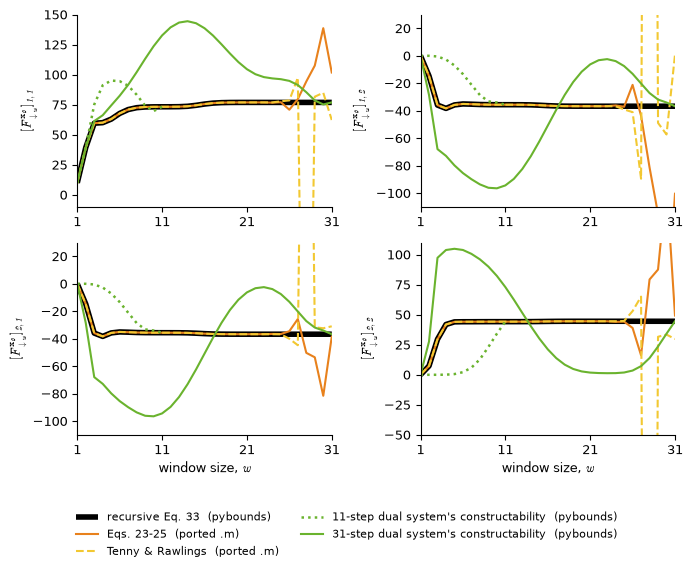

converged Gramian at w = 31:
[[ 76.931317398248 -36.700184322164]
 [-36.700184322164  44.543349910981]]


np.True_

In [10]:
As, Cs, Qs, Rs, n, p, N = duality_example()
ws = np.arange(1, N + 2)

recursive = np.array([pybounds_observability(As, Cs, Qs, Rs, w) for w in ws])

duals = {}
for W in (11, 31):
    Phis, Cw, Qds, Rw = zero_indexed(As, Cs, Qs, Rs, W)
    dual_Phis, dual_Cs, dual_Qinvs, dual_Rinvs = dual_system(Phis, Cw, Qds, Rw)
    duals[W] = np.array([stochastic.stochastic_constructability_gramian(
        dual_Phis[:m], dual_Cs[:m], dual_Qinvs[:m], dual_Rinvs[:m]) for m in range(1, W + 1)])

PHIs = duality_example_phis(As, n, N)
seed = Cs[1].T @ (inv(Rs[1]) @ Cs[1])
theorem_1 = np.array([seed] + [matlab_fim_theorem_1(As, Cs, Qs, Rs, PHIs, w, n, p) for w in range(2, N + 2)])
tenny = np.array([seed] + [matlab_fim_tenny_rawlings(As, Cs, Qs, Rs, w, n, p) for w in range(2, N + 2)])

with plt.rc_context({'font.size': 9, 'axes.linewidth': 0.8, 'mathtext.fontset': 'cm', 'mathtext.default': 'it'}):
    figure, axes = plt.subplots(2, 2, figsize=(7.0, 5.6))
    handles = None
    for ax, (i, j) in zip(axes.ravel(), [(0, 0), (0, 1), (1, 0), (1, 1)]):
        drawn = [ax.plot(ws, recursive[:, i, j], 'k', lw=4.0, solid_capstyle='butt')[0],
                 ax.plot(ws, theorem_1[:, i, j], color=ORANGE, lw=1.5)[0],
                 ax.plot(ws, tenny[:, i, j], '--', color=YELLOW, lw=1.5)[0],
                 ax.plot(np.arange(1, 12), duals[11][:, i, j], ':', color=DUALITY_GREEN, lw=1.8)[0],
                 ax.plot(ws, duals[31][:, i, j], color=DUALITY_GREEN, lw=1.5)[0]]
        handles = handles or drawn
        ax.set_ylabel(r'$[F_{\downarrow_{w}}^{\mathbf{x}_{0}}]_{%d,%d}$' % (i + 1, j + 1))
        ax.set_xlim(1, 31)
        ax.set_xticks([1, 11, 21, 31])
        ax.spines[['top', 'right']].set_visible(False)

    axes[0, 0].set_ylim(-10, 150)
    axes[0, 1].set_ylim(-110, 30)
    axes[1, 0].set_ylim(-110, 30)
    axes[1, 1].set_ylim(-50, 110)
    for ax in axes[1]:
        ax.set_xlabel(r'window size, $w$')

    figure.legend(handles,
                  ['recursive Eq. 33  (pybounds)',
                   'Eqs. 23-25  (ported .m)',
                   'Tenny & Rawlings  (ported .m)',
                   "11-step dual system's constructability  (pybounds)",
                   "31-step dual system's constructability  (pybounds)"],
                  loc='lower center', ncol=2, frameon=False, fontsize=8, bbox_to_anchor=(0.5, -0.02))
    figure.tight_layout(rect=(0, 0.12, 1, 1))
    plt.show()

print('converged Gramian at w = 31:')
print(recursive[-1])
converged_published = np.array([[76.931317, -36.700184], [-36.700184, 44.543350]])
report.check('Fig. 2 converged Gramian at w = 31', np.abs(recursive[-1] - converged_published).max(), 1e-5,
             'recorded value')

## Summary

In [11]:
report.summary()
assert report.ok, 'a validation check failed'

PASS A. observability vs MATLAB, w = 1..31                7.84e-16  (tolerance 1.0e-12)  exact to machine precision
PASS A. observability Gramian non-decreasing in w         9.60e-15  (tolerance 1.0e-10)  Loewner monotonicity
PASS B. constructability vs MATLAB, duality system        6.07e-16  (tolerance 1.0e-12)  exact to machine precision
PASS B. constructability vs MATLAB, Crassidis             2.24e-07  (tolerance 1.0e-05)  conditioning-limited, cond(Q) = 1e6
PASS B. constructability with prior (F0) vs MATLAB seed   2.59e-10  (tolerance 1.0e-05)  conditioning-limited
PASS C. dual constructability vs MATLAB iterates          6.10e-15  (tolerance 1.0e-11)  Fig. 2's green curves
PASS C. Theorem 1 endpoint                                1.35e-15  (tolerance 1.0e-11)  dual F_con == F_obs
PASS C. duality_check() helper                            1.35e-15  (tolerance 1.0e-11)  pybounds own assertion
PASS D. recursive formula stable for w >= 25              9.27e-10  (tolerance 1.0e-08)  wh

## The same recursions through `ObservabilityAnalysis`: where to place each window's result

On a nonlinear model, the `stochastic-*` methods of `ObservabilityAnalysis` linearize along the trajectory
($\Phi_k = e^{A_k \Delta t}$) and run the recursions above in every sliding window. Each window gives one number per
state, which has to be placed somewhere along the trajectory. The `alignment` setting chooses where:

- `'center'` (the default): at the window's center time-step, $w//2$, for every method, so all methods share one time
  axis;
- `'bounded_state'`: at the state the result actually bounds -- the window's **first** sample for stochastic
  observability (and the `bounds-*` methods), its **last** sample for stochastic constructability.

The system is the mono-camera example from `examples/`: a camera moving over the ground with speed $g$ at height $d$,
measuring optic flow $r = g/d$. Height is only observable while the speed changes.

In [12]:
from pybounds import Simulator, ObservabilityAnalysis

def f(X, U):
    g, d = X
    u = U[0]
    return [u, 0 * u]

def h(X, U):
    g, d = X
    return [g / d]

dt = 0.01
simulator = Simulator(f, h, dt=dt, state_names=['g', 'd'], input_names=['u'], measurement_names=['r'])

t = np.arange(0, 8.0, step=dt)
u = 2 * np.pi * 0.3 * np.cos(2 * np.pi * 0.3 * t)   # ground speed g = 0.1 + sin(2 pi 0.3 t)
t_sim, x_sim, u_sim, y_sim = simulator.simulate(x0={'g': 0.1, 'd': 0.5}, u={'u': u}, return_full_output=True)

R = {'r': 0.01}
Q = {'g': 1e-3, 'd': 1e-6}   # per-step process noise; height changes far less than speed

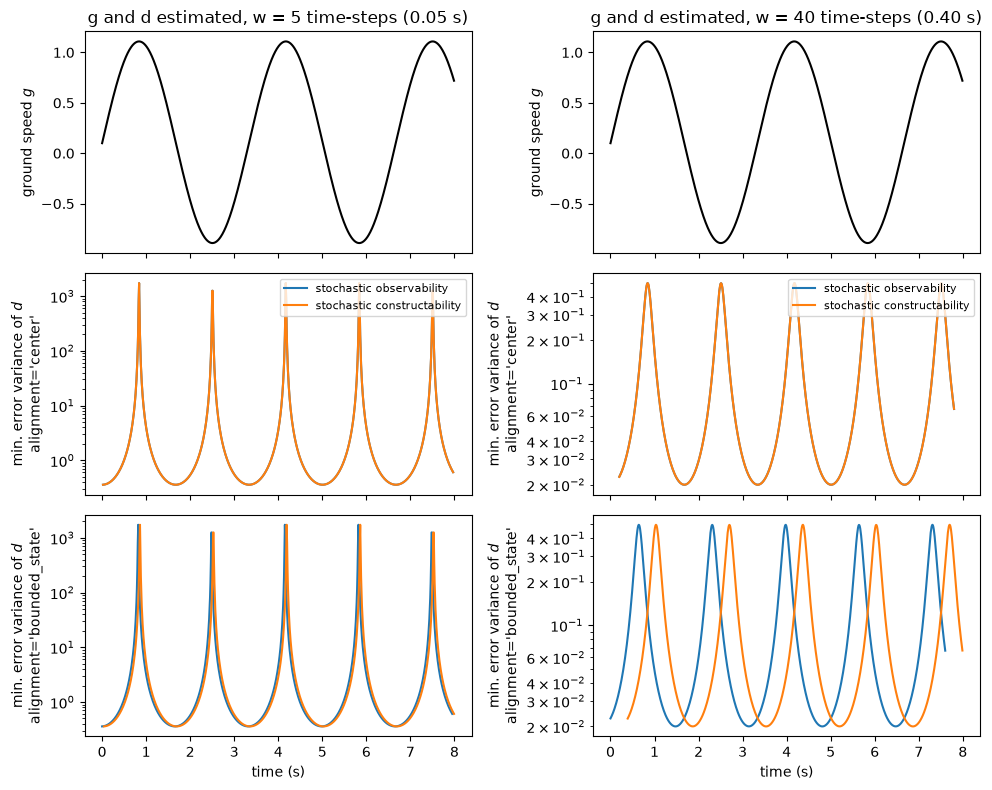

In [13]:
windows = (5, 40)
analyses = {(w, kind): ObservabilityAnalysis(simulator, t_sim, x_sim, u_sim, method=f'stochastic-{kind}-classic',
                                             w=w, R=R, Q=Q).run()
            for w in windows for kind in ('observability', 'constructability')}


def plot_alignments(states, windows, title):
    fig, axes = plt.subplots(3, len(windows), figsize=(5 * len(windows), 8), sharex=True, squeeze=False)
    for col, w in enumerate(windows):
        axes[0, col].plot(t_sim, x_sim['g'], color='black')
        axes[0, col].set_ylabel('ground speed $g$')
        axes[0, col].set_title(f'{title}, w = {w} time-steps ({w * dt:.2f} s)')
        for row, alignment in enumerate(('center', 'bounded_state'), start=1):
            ax = axes[row, col]
            for kind, color in (('observability', 'tab:blue'), ('constructability', 'tab:orange')):
                ev = analyses[w, kind].min_error_variance(states=states, alignment=alignment)
                ax.semilogy(ev['time'], ev['d'], color=color, label=f'stochastic {kind}')
            ax.set_ylabel(f"min. error variance of $d$\nalignment='{alignment}'")
        axes[1, col].legend(loc='upper right', fontsize=8)
    for ax in axes[-1]:
        ax.set_xlabel('time (s)')
    fig.tight_layout()
    plt.show()


plot_alignments(states=None, windows=windows, title='g and d estimated')

With `alignment='bounded_state'` the constructability curve trails the observability curve by $w-1$ time-steps: the
observability Gramian bounds the state at the start of each window, the constructability Gramian the state at its end,
and both see the same measurements. Placed at the window center, the two curves line up -- closely for a short window,
and here still well for a longer one, because the trajectory changes slowly relative to the window. So compare
methods at the window center, and read off *when* a state is (un)observable with `'bounded_state'`.

The `bounds-*` methods (no process noise) bound the window's initial state, so `'bounded_state'` places them like
stochastic observability.

**Which alignment lines up depends on the question asked.** Above, $g$ and $d$ are estimated together, and the
information about $d$ comes from how the measurements vary across the whole window. Selecting a single state is
*conditional*: the other states are treated as known -- here $g$, exactly, at the bounded state. With process noise,
$g$ at other times in the window is then still uncertain, so the information about $d$ is concentrated at the bounded
instant, and a feature of the result (the peaks, where $g$ crosses zero) is tied to the bounded state itself. Then it
is `'bounded_state'` that lines the two methods up:

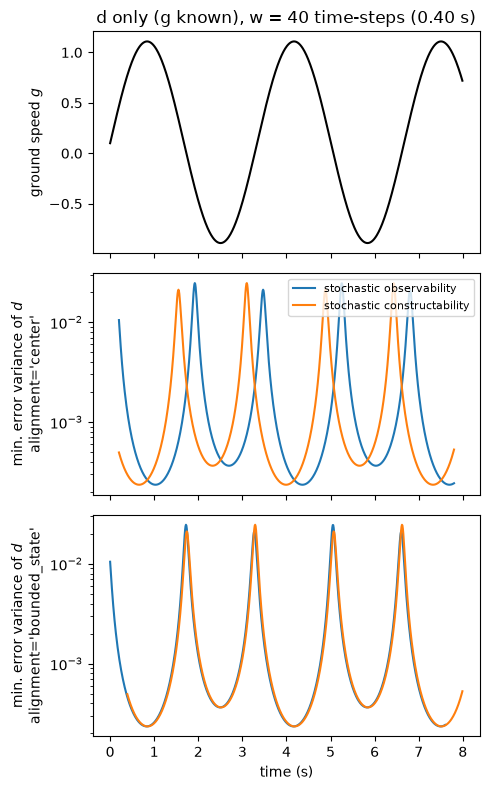

In [14]:
plot_alignments(states=['d'], windows=(40,), title='d only (g known)')

In [15]:
def mismatch(w, states, alignment):
    a, b = (analyses[w, kind].min_error_variance(states=states, alignment=alignment)['d'].to_numpy()
            for kind in ('observability', 'constructability'))
    ratio = np.abs(np.log(a / b))
    return np.median(ratio[~np.isnan(ratio)])

print('median |log(observability / constructability)| of the minimum error variance of d:')
print('%-26s %4s %14s %16s' % ('', 'w', "'center'", "'bounded_state'"))
for states, label in ((None, 'g and d estimated'), (['d'], 'd only (g known)')):
    for w in windows:
        print('%-26s %4d %14.2e %16.2e' % (label, w, mismatch(w, states, 'center'),
                                            mismatch(w, states, 'bounded_state')))

median |log(observability / constructability)| of the minimum error variance of d:
                              w       'center'  'bounded_state'
g and d estimated             5       1.06e-04         1.64e-01
g and d estimated            40       1.63e-03         1.16e+00
d only (g known)              5       6.66e-02         6.80e-02
d only (g known)             40       1.07e+00         5.89e-02
